# Лабораторная работа №2 — Задача классификации

#### Работу выполнил студент 303 группы Ефимов Сергей

### Тема:
##### Случайный лес, Градиентный бустинг, Метод опорных векторов (SVM), K-ближайших соседей (KNN)

### Датасет:
##### Telco Customer Churn (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

### Цель работы:
#### Освоить основные методы классификации и научиться проводить предобработку данных и разведочный анализ (EDA). Изучить задачу классификации, научиться замерять качество моделей классификации, интерпретировать метрики

### Задачи
1. Загрузить и изучить датасет:
2. Провести EDA: типы признаков, распределения, корреляции.
3. Очистить данные (удалить/заменить пропуски, привести типы, закодировать категориальные признаки где это требуется по особенности модели).
4. Разделить данные на обучающую и тестовую выборки.
5. Обучить модели:\
    a. RandomForestClassifier\
    b. Градиентный бустинг (любой на выбор, не из sklearn)\
    c. SVC (classifier SVM)\
    d. KNeighborsClassifier
6. Оценить качество моделей с помощью:\
    a. Accuracy,\
    b. Precision,\
    c. Recall,\
    d. F1-score,\
    e. ROC-AUC.
7. Построить матрицу ошибок и ROC-кривую.
8. Сделать вывод: какая модель показывает наилучший баланс метрик



#### В каждой строке данных содержится следующая информация
1. customerID -- Уникальный идентификатор клиента.

2. gender -- Пол клиента (мужчина/женщина).

3. SeniorCitizen -- Является ли клиент пожилым человеком (1 — да, 0 — нет).

4. Partner -- Есть ли у клиента партнёр/супруг(а).

5. Dependents -- Есть ли у клиента иждивенцы.

6. tenure -- Количество месяцев, в течение которых клиент пользуется услугами компании.

7. PhoneService -- Подключена ли у клиента телефонная связь.

8. MultipleLines -- Есть ли у клиента несколько телефонных линий.

9. InternetService -- Тип интернет-подключения (DSL, fiber, нет интернета).

10. OnlineSecurity -- Услуга онлайн-защиты (включена или нет).

11. OnlineBackup -- Услуга онлайн-резервного копирования данных.

12. DeviceProtection -- Услуга защиты устройств.

13. TechSupport -- Техническая поддержка (расширенная).

14. StreamingTV -- Услуга потокового телевидения.

15. StreamingMovies -- Услуга потоковых фильмов.

16. Contract -- Тип контракта (месячный, годовой, двухлетний).

17. PaperlessBilling -- Подключена ли электронная (безбумажная) система оплаты.

18. PaymentMethod -- Метод оплаты (банковская карта, электронный чек, автоматический платеж и др.).

19. MonthlyCharges -- Ежемесячные расходы клиента.

20. TotalCharges -- Общие расходы клиента за всё время.

21. Churn -- Ушёл ли клиент (да/нет).

### EDA

Пустых строк:  11
Размер:  (7043, 21)
Типы столбцов:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Пропуски:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Con

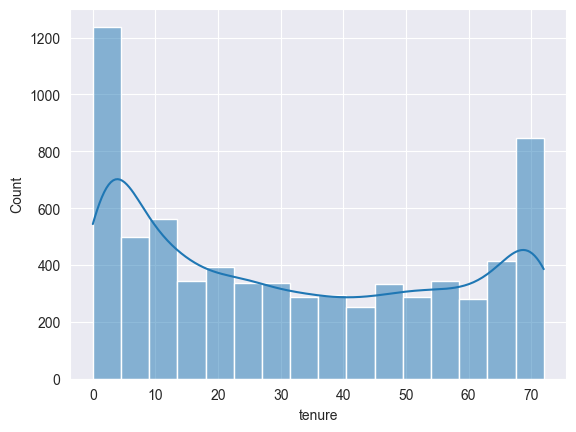

Распределение сколько клиенты тратят на услуги кампании


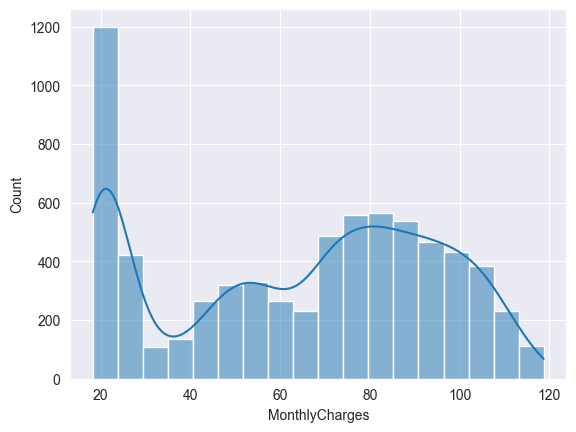

Анализ признаков


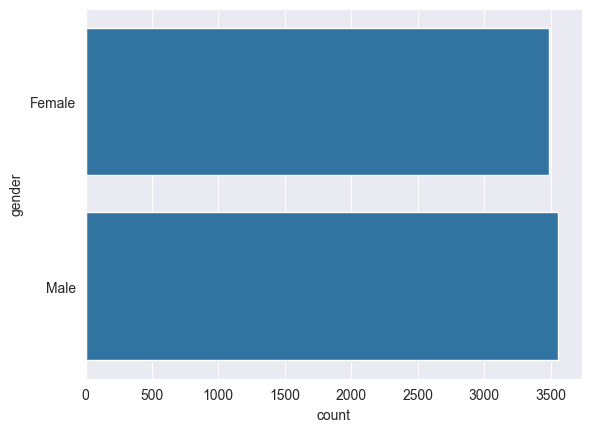

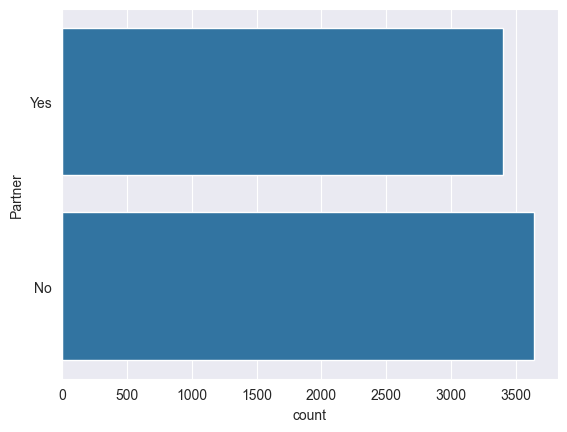

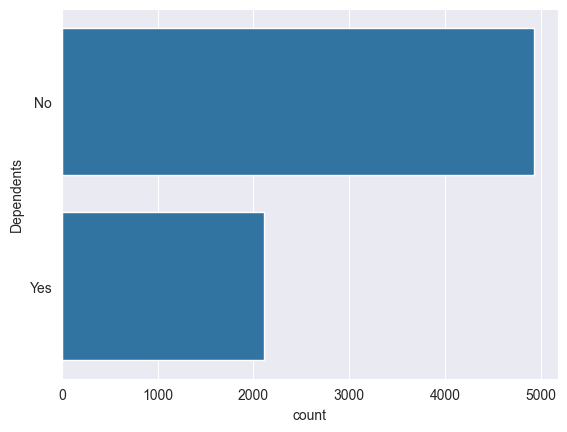

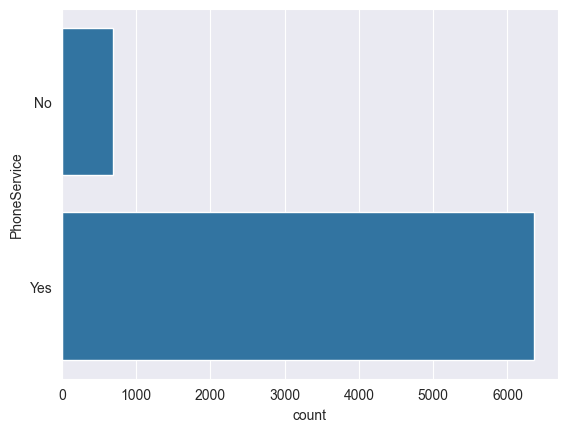

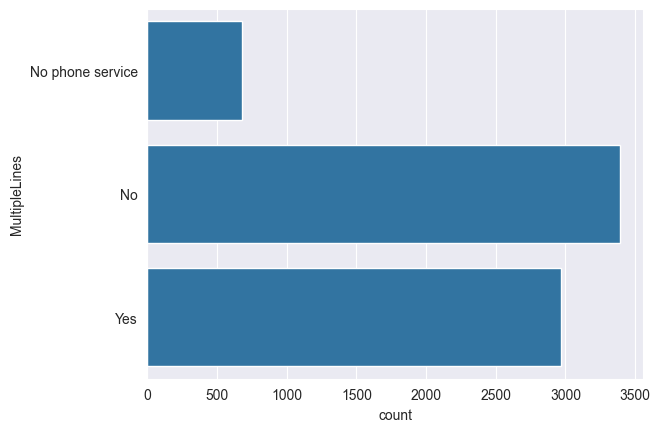

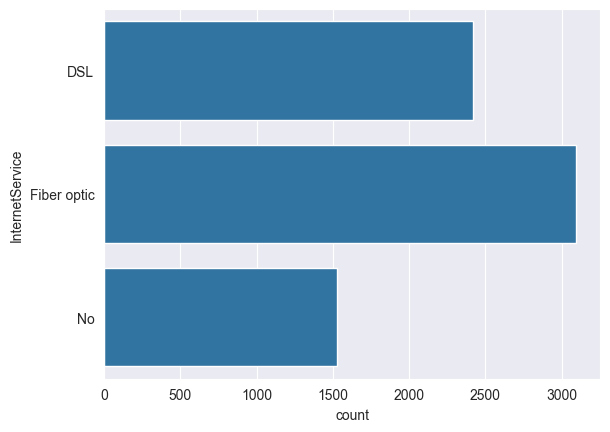

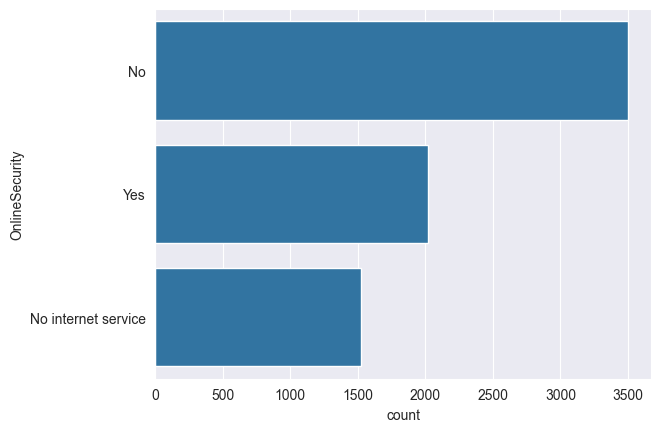

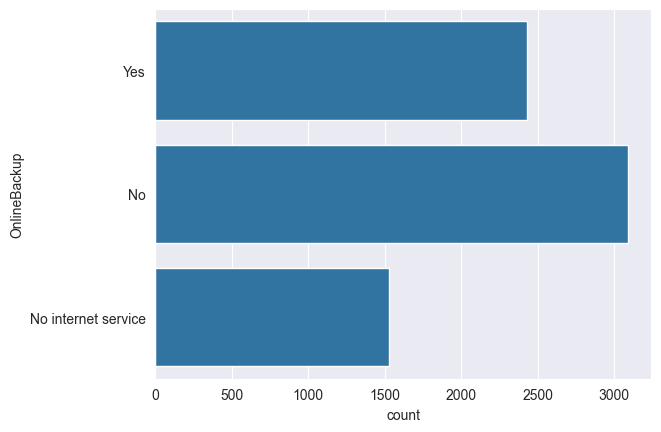

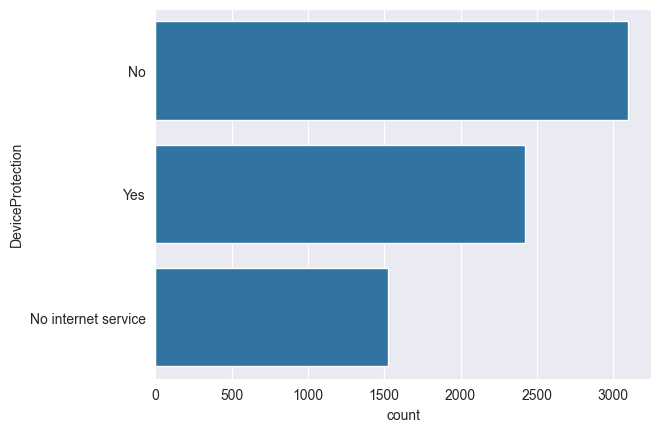

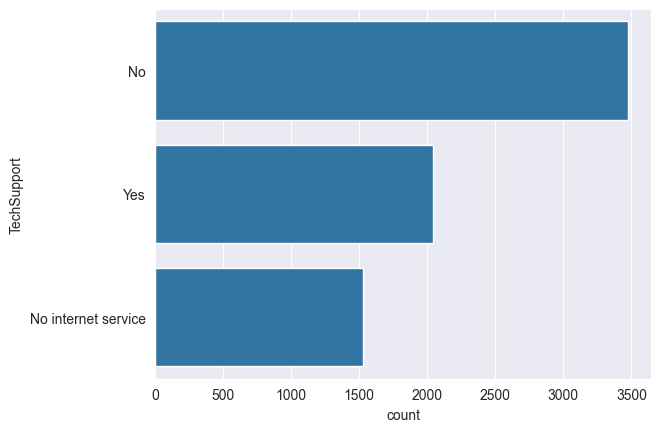

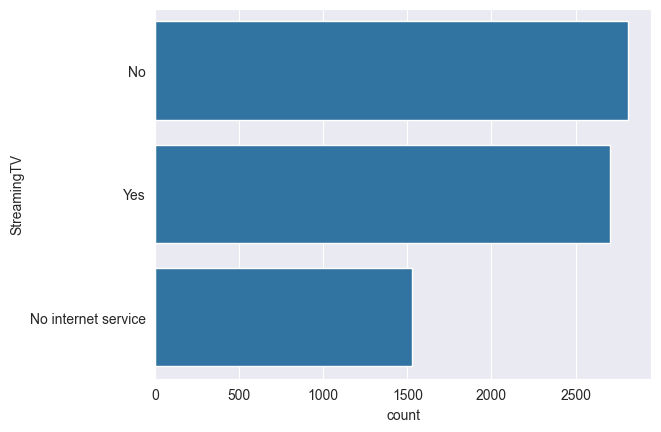

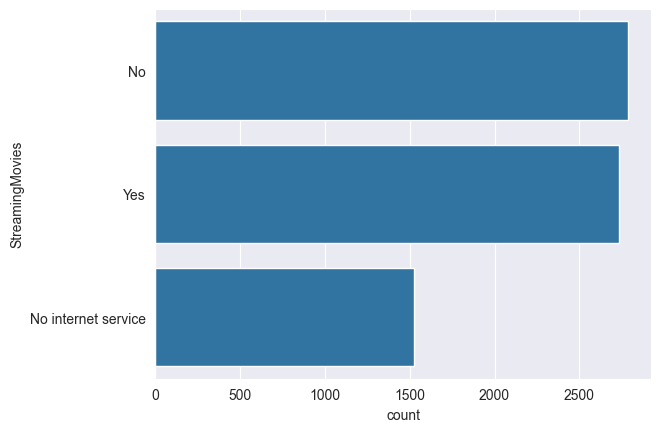

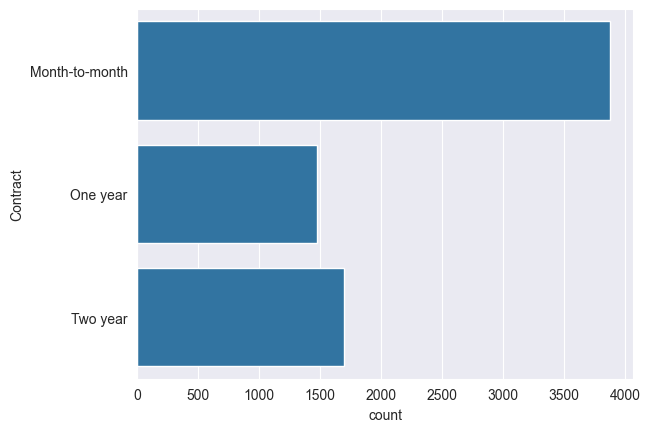

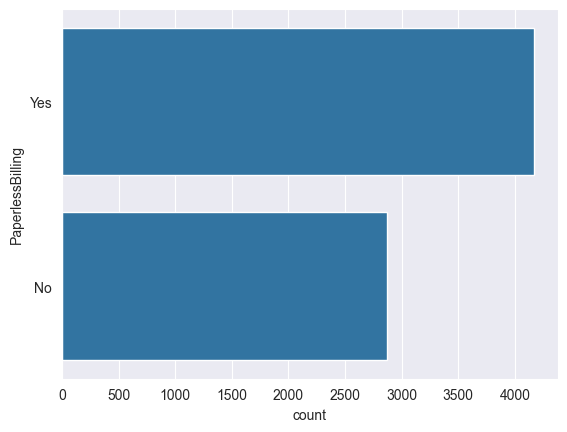

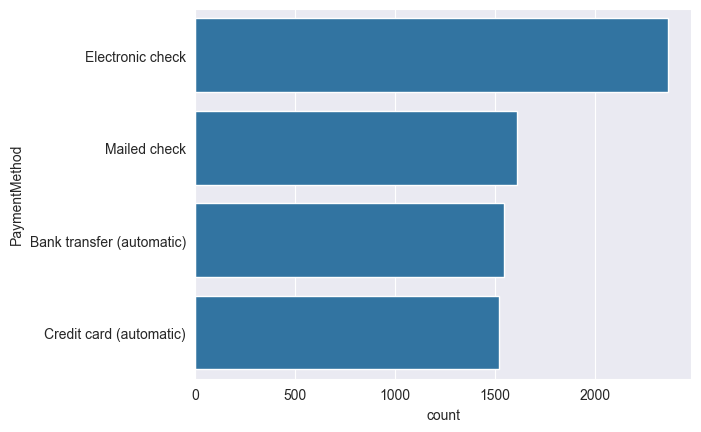

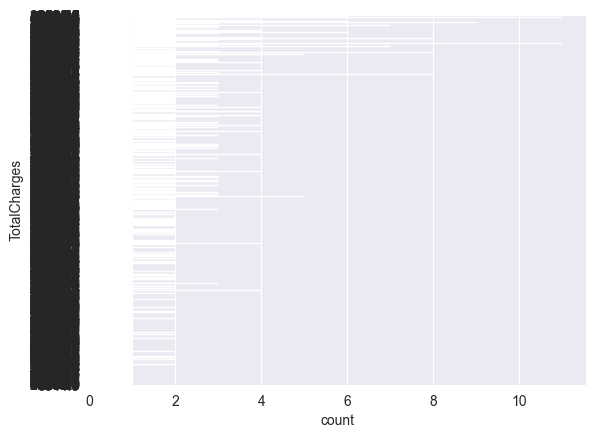

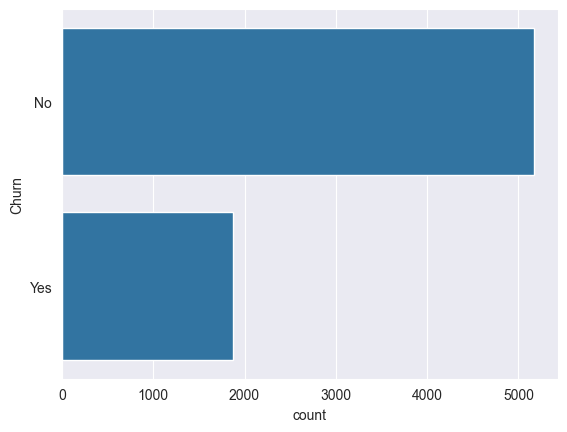

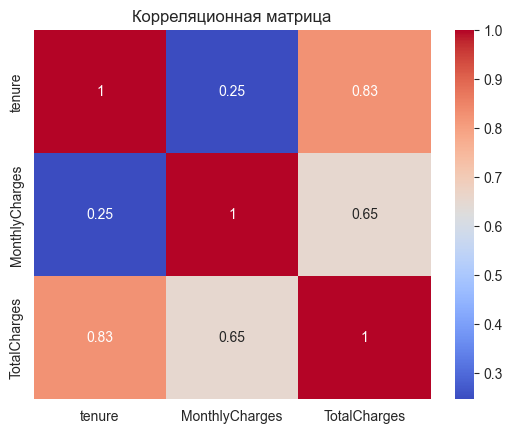

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/Telco-Customer-Churn.xls')

mask_blank = df['TotalCharges'].astype(str).str.strip() == ''
print('Пустых строк: ', mask_blank.sum())

print("Размер: ", df.shape)
print("Типы столбцов:\n", df.dtypes)
print("Пропуски:\n", df.isna().sum())

print("Статистики для числовых признаков:\n", df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

print("Распределение сколько клиенты пользуются услугами кампании")
sns.histplot(df['tenure'], kde=True)
plt.show()

print("Распределение сколько клиенты тратят на услуги кампании")
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

print("Анализ признаков")
cat_cols = [i for i in df.columns if df[i].dtype == 'object' and i != 'customerID']
for c in cat_cols:
    sns.countplot(y=c, data=df)
    plt.show()


df['TotalCharges'] = df['TotalCharges'].astype(str).str.strip().replace('', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_corr = df.dropna(subset=['TotalCharges']).copy()

corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Корреляционная матрица")
plt.show()

### Очистка данных

In [3]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print("сколько строк удалено: ", df['TotalCharges'].isna().sum())
df = df.dropna(subset=['TotalCharges'])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

df = df.drop('customerID', axis=1)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

сколько строк удалено:  11


### Создание обучающей и тестовой выборки

In [4]:
from sklearn.model_selection import train_test_split

print("Новые колонки:\n", df.columns)

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

Новые колонки:
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'PaperlessBilling_Yes', 'Churn_Yes'],
      dtype='object')


### Обучение моделей

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

from sklearn.svm import SVC

svc = SVC(kernel='rbf')

svc.fit(X_train, y_train)
svc_preds = svc.predict(X_test)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)


### Оценить качество моделей

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)
    return acc, prec, rec, f1, roc

rf_proba = rf.predict_proba(X_test)[:,1]
rf_metrics = evaluate_model(y_test, rf_preds, rf_proba)
print("Random Forest metrics (Accuracy, Precision, Recall, F1, ROC-AUC):", rf_metrics)

svc_proba = svc.decision_function(X_test)
svc_metrics = evaluate_model(y_test, svc_preds, svc_proba)
print("SVM metrics (Accuracy, Precision, Recall, F1, ROC-AUC):", svc_metrics)

knn_proba = knn.predict_proba(X_test)[:,1]
knn_metrics = evaluate_model(y_test, knn_preds, knn_proba)
print("KNN metrics (Accuracy, Precision, Recall, F1, ROC-AUC):", knn_metrics)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_metrics = evaluate_model(y_test, xgb_preds, xgb_proba)
print("XGBoost metrics (Accuracy, Precision, Recall, F1, ROC-AUC):", xgb_metrics)


Random Forest metrics (Accuracy, Precision, Recall, F1, ROC-AUC): (0.8009950248756219, 0.6631944444444444, 0.5106951871657754, 0.5770392749244713, 0.8405104803516056)
SVM metrics (Accuracy, Precision, Recall, F1, ROC-AUC): (0.7953091684434968, 0.6641221374045801, 0.46524064171123, 0.5471698113207547, 0.7971395809930062)
KNN metrics (Accuracy, Precision, Recall, F1, ROC-AUC): (0.7739872068230277, 0.5773480662983426, 0.5588235294117647, 0.5679347826086957, 0.7954325442224766)
XGBoost metrics (Accuracy, Precision, Recall, F1, ROC-AUC): (0.783226723525231, 0.6095238095238096, 0.5133689839572193, 0.5573294629898403, 0.8336253889041315)


### Матрица ошибок и ROC-кривая


Random Forest — Confusion Matrix


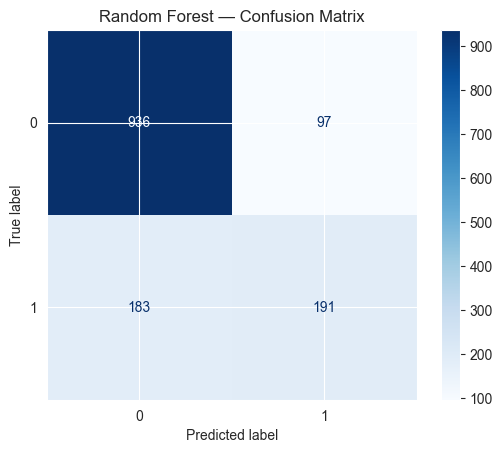


SVM — Confusion Matrix


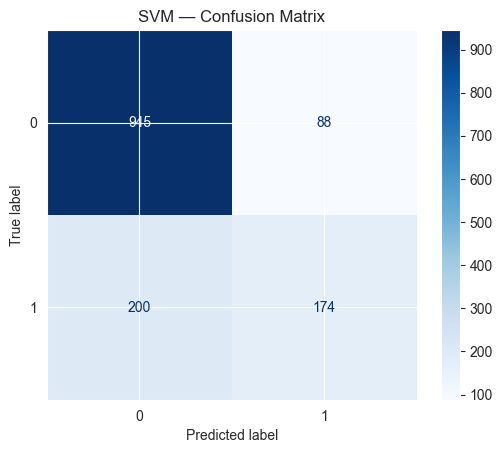


KNN — Confusion Matrix


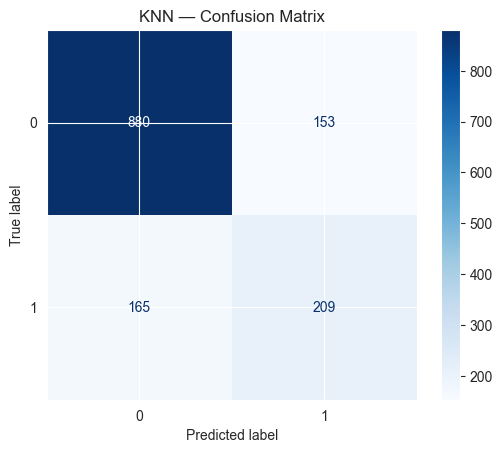


XGBoost — Confusion Matrix


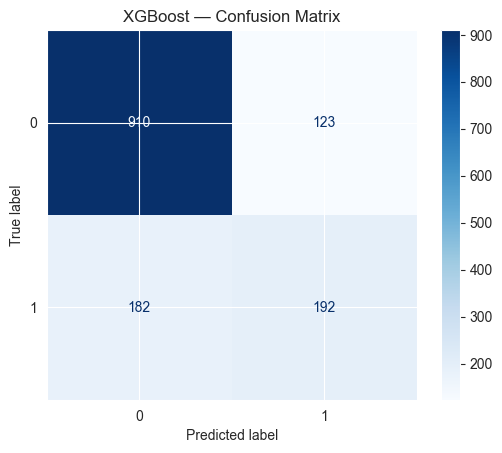

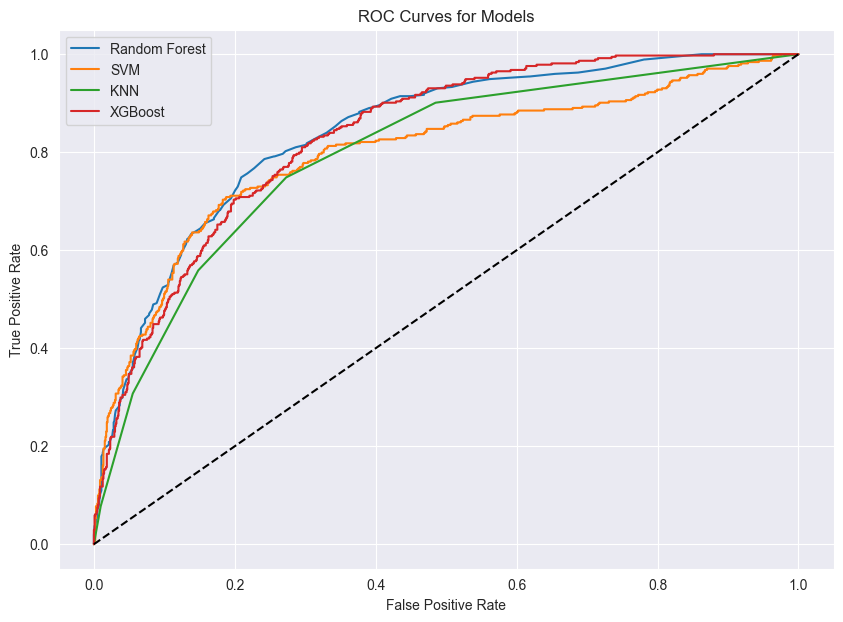

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

models = {
    "Random Forest": (rf_preds, rf_proba),
    "SVM": (svc_preds, svc_proba),
    "KNN": (knn_preds, knn_proba),
    "XGBoost": (xgb_preds, xgb_proba)
}

for name, (preds, proba) in models.items():
    print(f"\n{name} — Confusion Matrix")

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

plt.figure(figsize=(10, 7))

for name, (preds, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves for Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


### Выводы

Лучший ROC-AUC: XGBoost

Лучший Accuracy: SVM

Лучший Precision: SVM

Лучший Recall: KNN

Лучший F1-score: XGBoost

#### Лучшая модель: XGBoost

1 место по ROC-AUC и F1-score\
2 место по Accuracy и Recall\
3 место по Precision

Модель обладает оптимальными средними метриками, более менее уступая только в Precision

